In [1]:
import pandas as pd
import joblib
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import os
import time
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

# PRÉPARATION ET CHARGEMENT 

le = joblib.load('../models/label_encoder.pkl')
scaler = joblib.load('../models/scaler.pkl')
df = pd.read_csv("../data/cache_filtre.csv")

X = df.drop(columns=['label'])
y = le.transform(df['label'])

# smote
X_scaled = scaler.transform(X)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, stratify=y, random_state=42)

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)


X_train_rnn = X_train_res.reshape(X_train_res.shape[0], 1, X_train_res.shape[1])
X_test_rnn = X_test.reshape(X_test.shape[0], 1, X_test.shape[1])

n_features = X_train_rnn.shape[2]
n_classes = len(le.classes_)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

#  ARCHITECTURE DU MODÈLE HYBRIDE (GRU + LSTM) 
class HybridModel(nn.Module):
    def __init__(self, n_features, n_classes):
        super(HybridModel, self).__init__()
        # Couche GRU traitant l'entrée
        self.gru = nn.GRU(n_features, 256, batch_first=True)
        # Couche LSTM traitant la sortie du GRU
        self.lstm = nn.LSTM(256, 128, batch_first=True)
        
        self.bn = nn.BatchNorm1d(128)
        self.dropout = nn.Dropout(0.3)
        self.fc = nn.Sequential(
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, n_classes)
        )

    def forward(self, x):
        out, _ = self.gru(x)
        out, _ = self.lstm(out)
        out = out[:, -1, :] 
        out = self.bn(out)
        out = self.dropout(out)
        return self.fc(out)

model = HybridModel(n_features, n_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Création du DataLoader
train_loader = DataLoader(
    TensorDataset(torch.FloatTensor(X_train_rnn), torch.LongTensor(y_train_res)), 
    batch_size=1024, shuffle=True
)

#  ENTRAÎNEMENT ET ENREGISTREMENT DES DONNÉES 
history = {'loss': [], 'acc': [], 'lr': []}
num_epochs = 50

print(f"Début de l'entraînement hybride sur {device}...")

for epoch in range(num_epochs):
    start_time = time.time()
    model.train()
    total_loss, correct = 0, 0
    
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        correct += (outputs.argmax(1) == y_batch).sum().item()
    
    # Calcul des métriques de l'époque
    epoch_acc = (correct / len(y_train_res)) * 100
    epoch_loss = total_loss / len(train_loader)
    current_lr = optimizer.param_groups[0]['lr']
    
    # Stockage dans l'historique
    history['loss'].append(epoch_loss)
    history['acc'].append(epoch_acc)
    history['lr'].append(current_lr)
    
    duration = time.time() - start_time
    print(f"Epoch {epoch+1:02d}/50 | Loss: {epoch_loss:.4f} | Acc: {epoch_acc:.2f}% | LR: {current_lr}")



Début de l'entraînement hybride sur cpu...
Epoch 01/50 | Loss: 0.7608 | Acc: 69.68% | LR: 0.001
Epoch 02/50 | Loss: 0.6368 | Acc: 74.75% | LR: 0.001
Epoch 03/50 | Loss: 0.5999 | Acc: 76.37% | LR: 0.001
Epoch 04/50 | Loss: 0.5770 | Acc: 77.38% | LR: 0.001
Epoch 05/50 | Loss: 0.5564 | Acc: 78.18% | LR: 0.001
Epoch 06/50 | Loss: 0.5300 | Acc: 79.06% | LR: 0.001
Epoch 07/50 | Loss: 0.5084 | Acc: 79.86% | LR: 0.001
Epoch 08/50 | Loss: 0.4831 | Acc: 81.06% | LR: 0.001
Epoch 09/50 | Loss: 0.4572 | Acc: 82.40% | LR: 0.001
Epoch 10/50 | Loss: 0.4263 | Acc: 83.90% | LR: 0.001
Epoch 11/50 | Loss: 0.4143 | Acc: 84.43% | LR: 0.001
Epoch 12/50 | Loss: 0.4031 | Acc: 84.88% | LR: 0.001
Epoch 13/50 | Loss: 0.3914 | Acc: 85.28% | LR: 0.001
Epoch 14/50 | Loss: 0.3834 | Acc: 85.64% | LR: 0.001
Epoch 15/50 | Loss: 0.3756 | Acc: 85.94% | LR: 0.001
Epoch 16/50 | Loss: 0.3658 | Acc: 86.32% | LR: 0.001
Epoch 17/50 | Loss: 0.3601 | Acc: 86.53% | LR: 0.001
Epoch 18/50 | Loss: 0.3518 | Acc: 86.85% | LR: 0.001
Epo

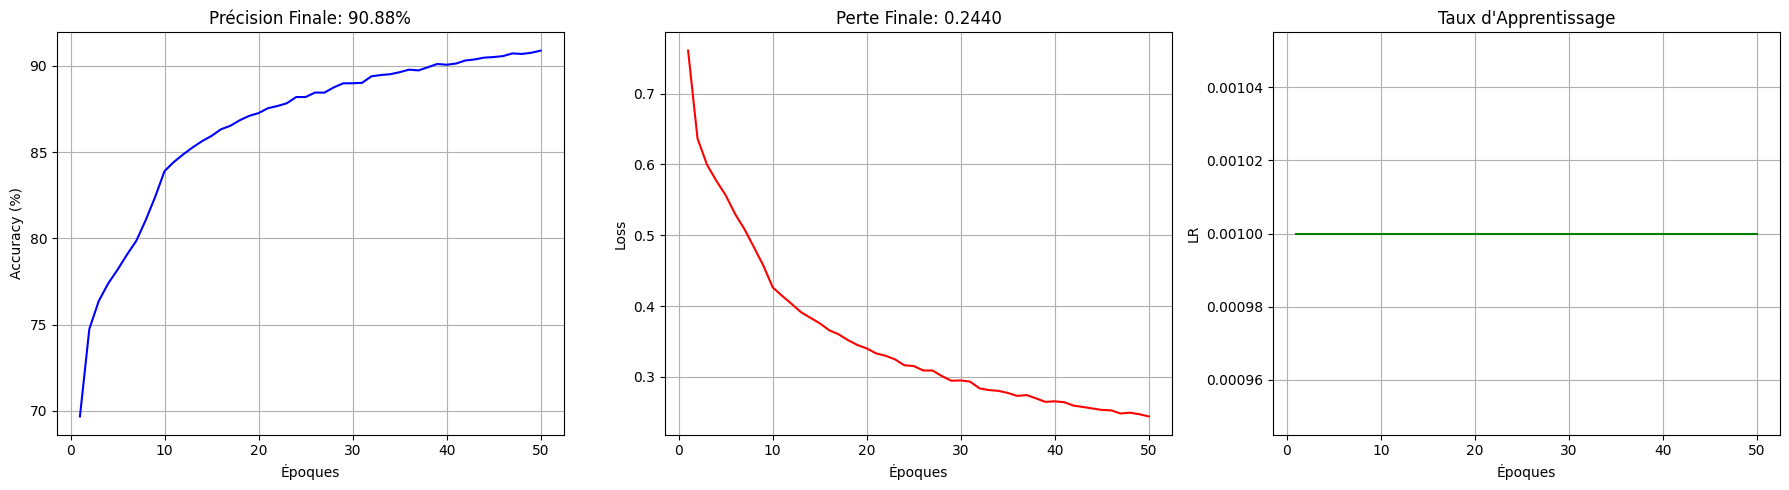

In [2]:
# RÉALISATION DES PLOTS 
epochs_range = range(1, num_epochs + 1)
plt.figure(figsize=(18, 5))

# Plot Accuracy
plt.subplot(1, 3, 1)
plt.plot(epochs_range, history['acc'], 'b-', label='Précision')
plt.title(f"Précision Finale: {history['acc'][-1]:.2f}%")
plt.xlabel('Époques')
plt.ylabel('Accuracy (%)')
plt.grid(True)

# Plot Loss
plt.subplot(1, 3, 2)
plt.plot(epochs_range, history['loss'], 'r-', label='Perte')
plt.title(f"Perte Finale: {history['loss'][-1]:.4f}")
plt.xlabel('Époques')
plt.ylabel('Loss')
plt.grid(True)

# Plot Learning Rate
plt.subplot(1, 3, 3)
plt.plot(epochs_range, history['lr'], 'g-', label='Learning Rate')
plt.title("Taux d'Apprentissage")
plt.xlabel('Époques')
plt.ylabel('LR')
plt.grid(True)

plt.tight_layout()
os.makedirs('../results', exist_ok=True)
plt.savefig('../results/courbes_performance_hybride.png')
plt.show()

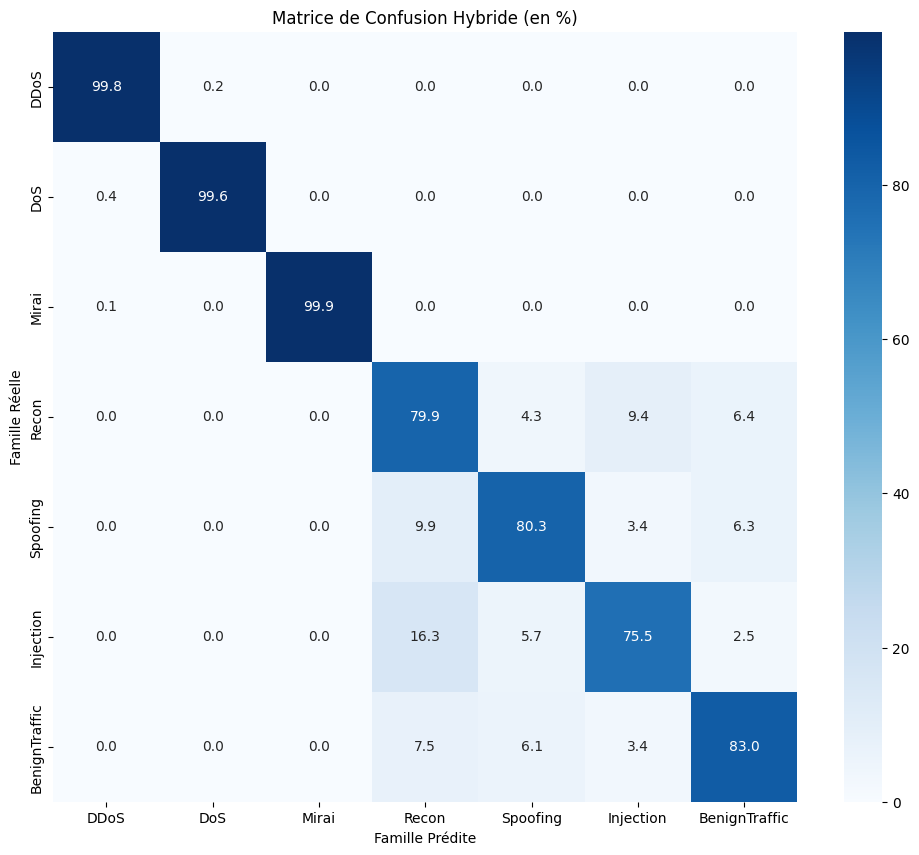

In [ ]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

# ÉVALUATION ET MATRICE DE CONFUSION 
model.eval() 
y_true = []
y_pred = []

# DataLoader pour le jeu de test
test_loader = DataLoader(
    TensorDataset(torch.FloatTensor(X_test_rnn), torch.LongTensor(y_test)), 
    batch_size=1024, shuffle=False
)

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        outputs = model(X_batch)
        predictions = outputs.argmax(1).cpu().numpy()
        y_true.extend(y_batch.numpy())
        y_pred.extend(predictions)

# Définition des familles cibles (à ajuster selon vos étiquettes)
FAMILLES = ['DDoS', 'DoS', 'Mirai', 'Recon', 'Spoofing', 'Injection', 'BenignTraffic']
noms_classes = le.classes_

def mapper_vers_famille(idx):
    label = noms_classes[idx]
    for f in FAMILLES:
        if f.lower() in label.lower(): return f
    return 'Other'

y_true_fam = [mapper_vers_famille(i) for i in y_true]
y_pred_fam = [mapper_vers_famille(i) for i in y_pred]

# Calcul de la matrice normalisée
cm = confusion_matrix(y_true_fam, y_pred_fam, labels=FAMILLES)
cm_perc = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

plt.figure(figsize=(12, 10))
sns.heatmap(cm_perc, annot=True, fmt='.1f', cmap='Blues', xticklabels=FAMILLES, yticklabels=FAMILLES)
plt.title('Matrice de Confusion Hybride (en %)')
plt.ylabel('Famille Réelle')
plt.xlabel('Famille Prédite')
os.makedirs('../results', exist_ok=True)
plt.savefig('../results/matrice_confusion_hybride.png')
plt.show()

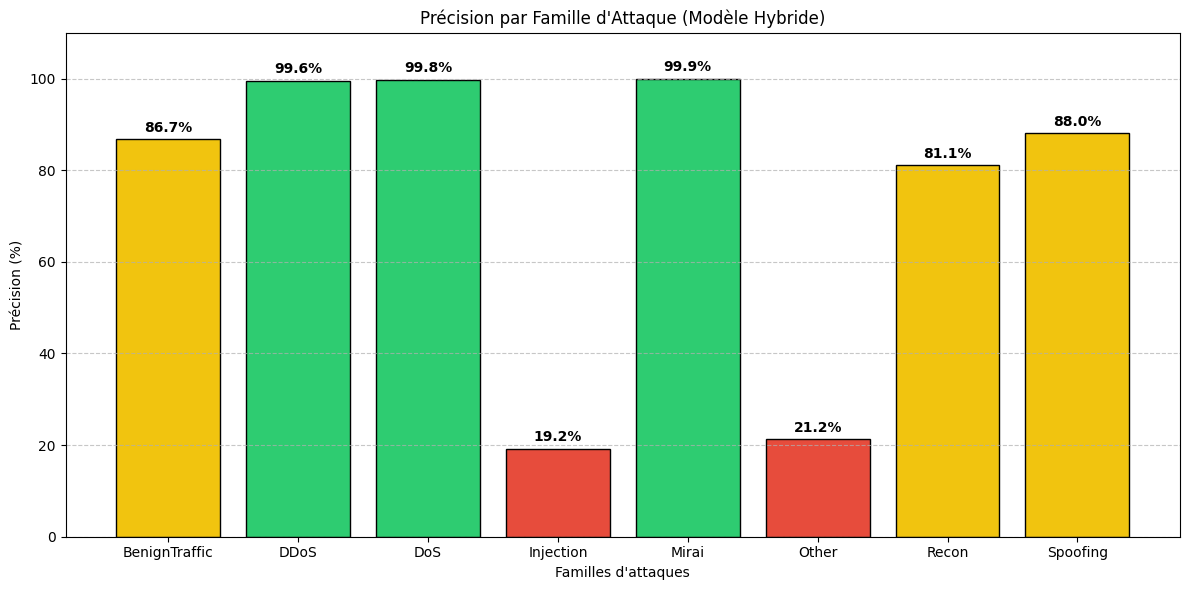

In [ ]:
from sklearn.metrics import classification_report

#  DIAGRAMME À BARRES DES PRÉCISIONS PAR CLASSE 
classes_presentes = np.unique(y_true_fam)

# Génération du rapport de classification 
report = classification_report(y_true_fam, y_pred_fam, output_dict=True)

# Extraction des précisions pour chaque classe présente
precision_values = [report[label]['precision'] * 100 for label in classes_presentes]

plt.figure(figsize=(12, 6))

# Attribution de couleurs (Vert si >= 90%, Jaune si >= 80%, Rouge sinon)
colors = ['#2ecc71' if p >= 90 else '#f1c40f' if p >= 80 else '#e74c3c' for p in precision_values]

bars = plt.bar(classes_presentes, precision_values, color=colors, edgecolor='black')

# Ajout des scores au-dessus de chaque barre
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1, f'{yval:.1f}%', 
             ha='center', va='bottom', fontweight='bold')

plt.title('Précision par Famille d\'Attaque (Modèle Hybride)')
plt.ylabel('Précision (%)')
plt.xlabel('Familles d\'attaques')
plt.ylim(0, 110)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
# Sauvegarde dans le dossier results défini dans vos fichiers
os.makedirs('../results', exist_ok=True)
plt.savefig('../results/precision_barres_hybride.png')
plt.show()

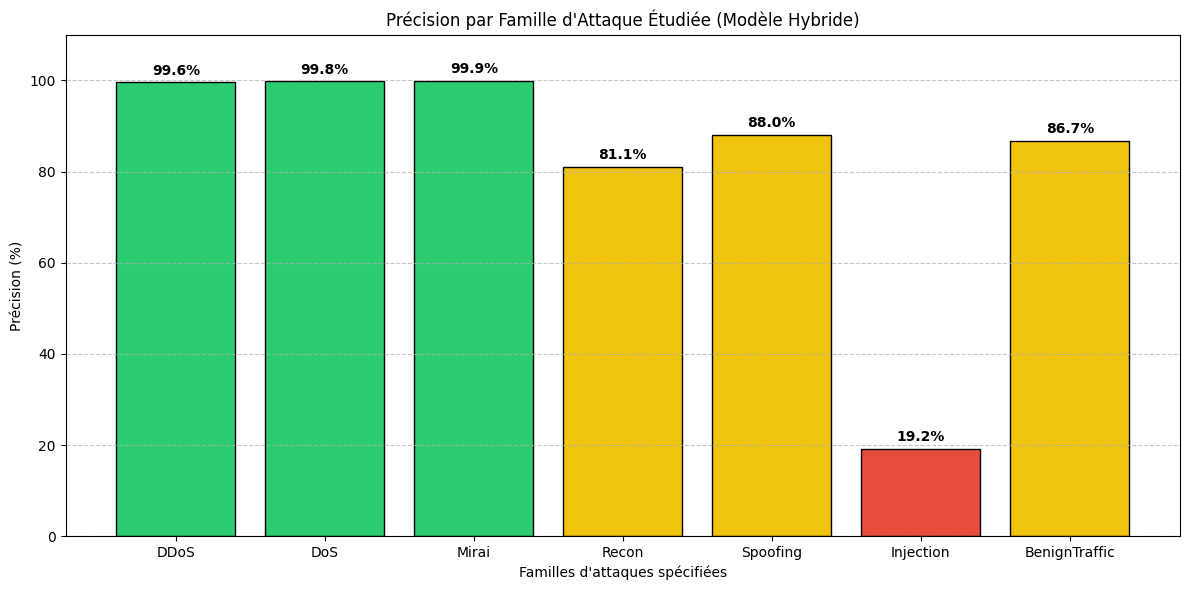

In [7]:
from sklearn.metrics import classification_report


FAMILLES_ETUDIEES = ['DDoS', 'DoS', 'Mirai', 'Recon', 'Spoofing', 'Injection', 'BenignTraffic']


report = classification_report(y_true_fam, y_pred_fam, output_dict=True)

# Extraction des précisions uniquement pour vos classes
precision_values = []
labels_valides = []

for famille in FAMILLES_ETUDIEES:
    if famille in report:
        precision_values.append(report[famille]['precision'] * 100)
        labels_valides.append(famille)

plt.figure(figsize=(12, 6))

# Attribution de couleurs selon la performance
colors = ['#2ecc71' if p >= 90 else '#f1c40f' if p >= 80 else '#e74c3c' for p in precision_values]

bars = plt.bar(labels_valides, precision_values, color=colors, edgecolor='black')

# Ajout des scores au-dessus de chaque barre
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1, f'{yval:.1f}%', 
             ha='center', va='bottom', fontweight='bold')

plt.title('Précision par Famille d\'Attaque Étudiée (Modèle Hybride)')
plt.ylabel('Précision (%)')
plt.xlabel('Familles d\'attaques spécifiées')
plt.ylim(0, 110)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
# Sauvegarde dans votre dossier de résultats
plt.savefig('../results/precision_barres_hybride_final.png')
plt.show()

In [8]:
import torch
import os

# Créer le dossier 'models' s'il n'existe pas encore
os.makedirs('../models', exist_ok=True)

# Sauvegarder uniquement les poids entraînés du modèle (Recommandé en PyTorch)
PATH_MODELE = '../models/model_hybride.pth'
torch.save(model.state_dict(), PATH_MODELE)

print(f"Le fichier du modèle a été créé avec succès ici : {PATH_MODELE}")

Le fichier du modèle a été créé avec succès ici : ../models/model_hybride.pth
